# Exploratory Data Analysis

Notebook ini menampilkan visualisasi utama dari dataset serta hasil prediksi model yang sudah dilatih.

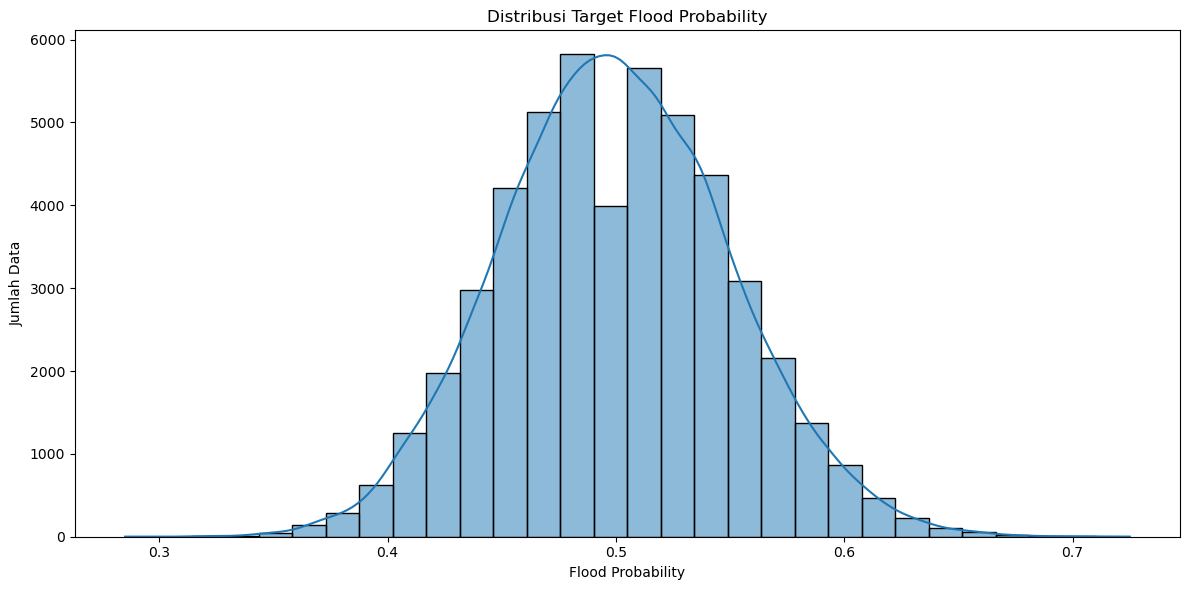

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

flood_df = pd.read_csv('../datasets/raw/flood.csv')

plt.figure(figsize=(12, 6))
sns.histplot(flood_df['FloodProbability'], bins=30, kde=True)
plt.title('Distribusi Target Flood Probability')
plt.xlabel('Flood Probability')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

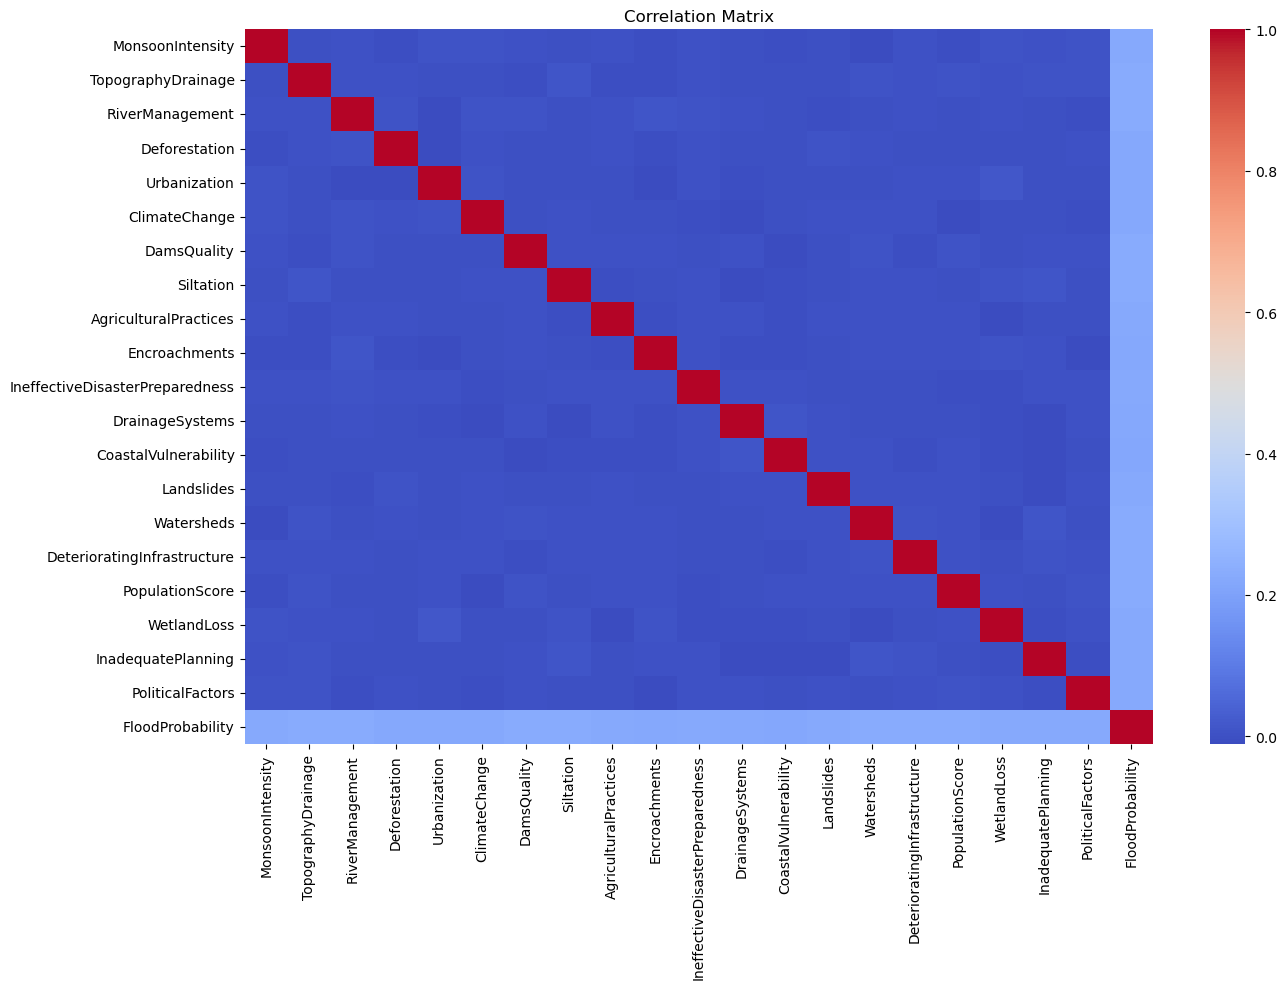

In [2]:
corr = flood_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [3]:
import sys
sys.path.append('..')
from src.predict import predict

payload = {
    'district_id': 'patrang',
    'district_profile': {'elevation': 84, 'drainage_score': 0.72, 'population_density': 4200},
    'weather_history': [
        {'rainfall': 40, 'humidity': 82, 'temperature': 24},
        {'rainfall': 35, 'humidity': 80, 'temperature': 25},
        {'rainfall': 50, 'humidity': 84, 'temperature': 26},
        {'rainfall': 45, 'humidity': 83, 'temperature': 25},
        {'rainfall': 55, 'humidity': 85, 'temperature': 24},
        {'rainfall': 60, 'humidity': 86, 'temperature': 25},
        {'rainfall': 70, 'humidity': 88, 'temperature': 26},
    ],
    'reports': {'flood_reports_24h': 12, 'waste_reports_24h': 26},
}

result = predict(payload)
result

{'district_id': 'patrang',
 'district_name': 'Patrang',
 'risk_score': 45.07,
 'risk_level': 'MEDIUM',
 'confidence': 0.4507,
 'recommendations': ['Continue routine inspections',
  'Monitor rainfall and river conditions',
  'Coordinate with community volunteers'],
 'priority_score': 27.04,
 'explanation': {'main_factors': ['recent rainfall intensity',
   'weather persistence over last 3-7 days',
   'district drainage and elevation profile',
   'recent flood and waste report volume']}}